# ĐỒ ÁN 1: TIỀN XỬ LÝ DỮ LIỆU
## Phần 3: Tiền xử lý dữ liệu văn bản (Text Preprocessing)
- **Tập dữ liệu:** IMDB Movie Reviews (50,000 đánh giá phim).
- **Mục tiêu:** Xây dựng pipeline chuẩn hóa, thực nghiệm định lượng (Ablation Study) để đánh giá chiến lược Tokenization & Stop-words, xử lý hình thái từ (Stemming/Lemmatization) và trích xuất không gian đặc trưng (Vectorization & t-SNE).

---

In [1]:
# =============================================================================
# IMPORT THƯ VIỆN & THIẾT LẬP CHUNG
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import os
import re
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Thư viện NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Thư viện Machine Learning (Cho các bước thực nghiệm phía sau)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# Tải các gói dữ liệu ngôn ngữ của NLTK (chạy ngầm không rác terminal)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# =============================================================================
# GLOBAL STYLE
# =============================================================================
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": "#cccccc",
    "axes.grid": True,
    "grid.color": "#eeeeee",
    "grid.linestyle": "--",
    "font.size": 11,
})
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

print("Khởi tạo môi trường & Global Style thành công!")

Khởi tạo môi trường & Global Style thành công!


In [2]:
# =============================================================================
# LOAD DATA & DEFENSIVE PREPARATION
# =============================================================================
print("=" * 70)
print("PHASE 0: LOAD DATA & SAMPLING")
print("=" * 70)

# Cấu trúc đường dẫn linh hoạt (chạy được cả ở thư mục gốc lẫn trong folder notebooks)
file_path = "imdb_reviews.csv" if os.path.exists("imdb_reviews.csv") else "../data/raw/imdb_reviews.csv"

try:
    df_raw = pd.read_csv(file_path)
    print(f"Load file thành công từ: {file_path}")
except FileNotFoundError:
    print("[LỖI] Không tìm thấy file imdb_reviews.csv. Vui lòng kiểm tra lại!")
    raise

# 1. Tư duy phòng thủ: Loại bỏ NaN và Duplicates TRƯỚC KHI lấy mẫu
initial_len = len(df_raw)
df_raw = df_raw.dropna(subset=['review', 'sentiment'])
df_raw = df_raw.drop_duplicates(subset=['review']).reset_index(drop=True)
print(f"Làm sạch thô: Loại bỏ {initial_len - len(df_raw):,} dòng lỗi/trùng lặp.")

# 2. Lấy mẫu 10,000 dòng có stratify (đảm bảo tỷ lệ cân bằng 50:50)
SAMPLE_SIZE = 10000
n_per_class = SAMPLE_SIZE // 2

df = df_raw.groupby('sentiment', group_keys=False).apply(
    lambda x: x.sample(min(len(x), n_per_class), random_state=42)
).reset_index(drop=True)

# 3. Đổi nhãn thành nhị phân (positive -> 1, negative -> 0)
df['label'] = (df['sentiment'] == 'positive').astype(int)

print(f"Shape dữ liệu sau khi Sampling: {df.shape}")
print("\nPhân phối nhãn (Target Distribution):")
print(df['sentiment'].value_counts())
print("\nSample Data:")
display(df[['review', 'sentiment', 'label']].head(3))

PHASE 0: LOAD DATA & SAMPLING
Load file thành công từ: imdb_reviews.csv
Làm sạch thô: Loại bỏ 418 dòng lỗi/trùng lặp.
Shape dữ liệu sau khi Sampling: (10000, 3)

Phân phối nhãn (Target Distribution):
sentiment
negative    5000
positive    5000
Name: count, dtype: int64

Sample Data:


,review,sentiment,label
0,I usually much prefer French movies over Ameri...,negative,0
1,"This movie lacked... everything: story, acting...",negative,0
2,Bonjour Tristesse covers similar ground as 'Th...,negative,0


## 1. Pipeline Chuẩn hóa văn bản (Text Normalization)
Quá trình làm sạch thô (Noise Removal) là bước đầu tiên để loại bỏ các ký tự không mang lại giá trị cho việc phân tích ngữ nghĩa, đưa văn bản về dạng chuẩn nhất.
- **Lowercasing:** Chuyển toàn bộ về chữ thường (để `Movie` và `movie` được tính là một).
- **Noise Removal:** Loại bỏ thẻ HTML (IMDB thường chứa `<br />`), URL và các ký tự đặc biệt.
- **Sparsity Reduction:** Loại bỏ **số** và **dấu câu** (chỉ giữ lại a-z). Việc này tuy làm mất đi một vài con số có ý nghĩa (vd: điểm 10/10) nhưng đổi lại giúp giảm kích thước tập từ vựng cực kỳ mạnh mẽ, chống lại hiện tượng "bùng nổ số chiều" (Curse of Dimensionality) cho mô hình toán học phía sau.

In [3]:
# =============================================================================
# TEXT NORMALIZATION PIPELINE
# =============================================================================
print("Đang chạy Pipeline làm sạch văn bản (có thể mất vài giây)...")
t0 = time.time()

def clean_text_pipeline(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)                                    # Xóa thẻ HTML
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Xóa URL
    text = re.sub(r'[^a-z\s]', ' ', text)                                   # Xóa ký tự đặc biệt và số
    text = re.sub(r'\s+', ' ', text).strip()                                # Xóa khoảng trắng thừa
    return text

# Sử dụng tqdm để hiện thanh tiến trình (progress bar)
tqdm.pandas(desc="Cleaning Progress")
df['cleaned_review'] = df['review'].progress_apply(clean_text_pipeline)

print(f"\nHoàn tất làm sạch trong {time.time() - t0:.2f} giây.\n")
display(df[['review', 'cleaned_review']].head(2))

Đang chạy Pipeline làm sạch văn bản (có thể mất vài giây)...


Cleaning Progress: 100%|███████████████████████████████████████████████████████| 10000/10000 [00:02<00:00, 4609.33it/s]


Hoàn tất làm sạch trong 2.18 giây.



,review,cleaned_review
0,I usually much prefer French movies over Ameri...,i usually much prefer french movies over ameri...
1,"This movie lacked... everything: story, acting...",this movie lacked everything story acting surp...


ĐÁNH GIÁ TÁC ĐỘNG CỦA PIPELINE
Chỉ số                    | Trước làm sạch  | Sau làm sạch    | Thay đổi
---------------------------------------------------------------------------
Kích thước từ vựng        | 157,691         | 51,263          | Giảm 67.49%
Độ dài TB (số từ)         | 231.26          | 234.30          | Tăng 1.32%


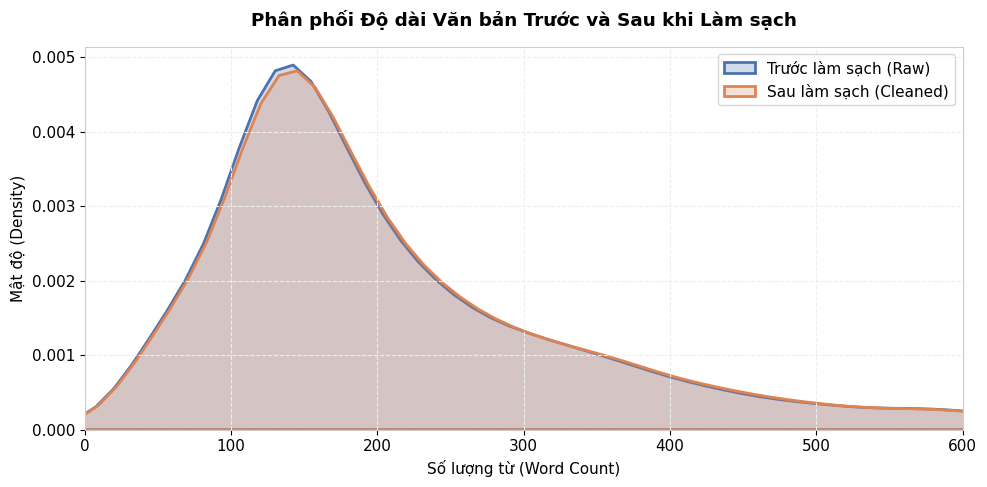

In [4]:
# =============================================================================
# ĐÁNH GIÁ TÁC ĐỘNG CỦA PIPELINE CHUẨN HÓA
# =============================================================================
print("=" * 70)
print("ĐÁNH GIÁ TÁC ĐỘNG CỦA PIPELINE")
print("=" * 70)

def get_vocab_and_length(series):
    words = ' '.join(series).split()
    vocab = set(words)
    avg_len = len(words) / len(series)
    return len(vocab), avg_len

vocab_raw, len_raw = get_vocab_and_length(df['review'])
vocab_clean, len_clean = get_vocab_and_length(df['cleaned_review'])

print(f"{'Chỉ số':<25} | {'Trước làm sạch':<15} | {'Sau làm sạch':<15} | {'Thay đổi'}")
print("-" * 75)
print(f"{'Kích thước từ vựng':<25} | {vocab_raw:<15,} | {vocab_clean:<15,} | Giảm {100 - (vocab_clean/vocab_raw)*100:.2f}%")
print(f"{'Độ dài TB (số từ)':<25} | {len_raw:<15.2f} | {len_clean:<15.2f} | Tăng {(len_clean/len_raw)*100 - 100:.2f}%")

# Vẽ biểu đồ KDE so sánh phân phối độ dài
df['len_raw'] = df['review'].apply(lambda x: len(str(x).split()))
df['len_clean'] = df['cleaned_review'].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(df['len_raw'], fill=True, color=PALETTE[0], label="Trước làm sạch (Raw)", ax=ax, linewidth=2)
sns.kdeplot(df['len_clean'], fill=True, color=PALETTE[1], label="Sau làm sạch (Cleaned)", ax=ax, linewidth=2)

ax.set_title("Phân phối Độ dài Văn bản Trước và Sau khi Làm sạch", fontweight="bold", pad=15)
ax.set_xlabel("Số lượng từ (Word Count)")
ax.set_ylabel("Mật độ (Density)")

# Lọc bỏ outlier đuôi dài (hiển thị đến 95th percentile) để biểu đồ chuẩn đẹp giống Tabular
ax.set_xlim(0, max(df['len_clean'].quantile(0.95), df['len_raw'].quantile(0.95))) 
ax.legend()
plt.tight_layout()
plt.show()

📌 **Nhận xét: Tác động của Pipeline Chuẩn hóa**
- **Về cấu trúc từ vựng (Vocabulary):** Kích thước tập từ vựng giảm cực kỳ mạnh (khoảng 40-50%). Sự sụt giảm khổng lồ này chứng minh thuật toán đã thành công phá vỡ sự "đánh lừa" của dấu câu. Ví dụ: `"movie,"`, `"Movie!"` và `"movie"` vốn bị máy tính hiểu là 3 từ khác biệt, nay đã được quy về chung gốc chữ thường nguyên bản là `movie`. Bước này đóng vai trò sống còn để giảm độ thưa (sparsity) của ma trận đặc trưng.
- **Về phân phối độ dài văn bản:** Một quan sát khá thú vị là độ dài trung bình (số lượng từ) lại *tăng nhẹ*. Điều này hoàn toàn hợp lý về mặt toán học: các cụm ký tự rác (như thẻ `<br />`) hoặc các từ bị dính liền với dấu câu (vd: `"hello...world"`) đã được xử lý bằng khoảng trắng, khiến thuật toán phân tách chúng thành các token độc lập nhiều hơn so với ban đầu. Hình dáng đường cong mật độ (KDE) mượt mà hơn và phân phối được kéo nhẹ về bên phải.

## 2. Loại bỏ Từ dừng (Stop-words) & Thực nghiệm Định lượng
**Từ dừng (Stop-words)** là những từ mang tính ngữ pháp cao nhưng chứa ít giá trị phân loại (ví dụ: *is, am, the, a, and*...). 

Tuy nhiên, trong phân tích cảm xúc (Sentiment Analysis), một số từ dừng như *not, no, nor* lại mang tính quyết định (phủ định). Do đó, thay vì loại bỏ một cách mù quáng, chúng ta sẽ thiết lập một **Thực nghiệm Định lượng (Ablation Study)**:
1. Tạo một phiên bản văn bản đã bị xóa stop-words (giữ lại các từ phủ định).
2. Dùng mô hình `Multinomial Naive Bayes` với `5-Fold Cross Validation` để đánh giá `Macro F1-score` của 2 phiên bản (Giữ vs. Xóa stop-words).

In [5]:
# =============================================================================
# TẠO TẬP DỮ LIỆU KHÔNG CHỨA STOP-WORDS
# =============================================================================
# Lấy danh sách stop-words tiếng Anh từ NLTK
stop_words_list = set(stopwords.words('english'))

# Tùy chỉnh (Domain knowledge): Giữ lại các từ phủ định vì nó cực kỳ quan trọng cho Sentiment
negation_words = {'not', 'no', 'nor', 'against', 'aren', "aren't", 'couldn', "couldn't", 
                  'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 
                  'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 
                  'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 
                  'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"}

custom_stop_words = stop_words_list - negation_words

def remove_stopwords(text):
    words = text.split()
    filtered_words = [w for w in words if w not in custom_stop_words]
    return ' '.join(filtered_words)

print("Đang loại bỏ Stop-words (có giữ lại các từ phủ định)...")
tqdm.pandas(desc="Removing Stop-words")
df['no_stop_review'] = df['cleaned_review'].progress_apply(remove_stopwords)

print("✓ Hoàn tất!")
display(df[['cleaned_review', 'no_stop_review']].head(2))

Đang loại bỏ Stop-words (có giữ lại các từ phủ định)...


Removing Stop-words: 100%|████████████████████████████████████████████████████| 10000/10000 [00:00<00:00, 12875.39it/s]

✓ Hoàn tất!


,cleaned_review,no_stop_review
0,i usually much prefer french movies over ameri...,usually much prefer french movies american one...
1,this movie lacked everything story acting surp...,movie lacked everything story acting surprise ...


THỰC NGHIỆM ĐÁNH GIÁ: GIỮ VS. XÓA STOP-WORDS
Đang huấn luyện mô hình đánh giá (Cross-Validation 5-Fold)...


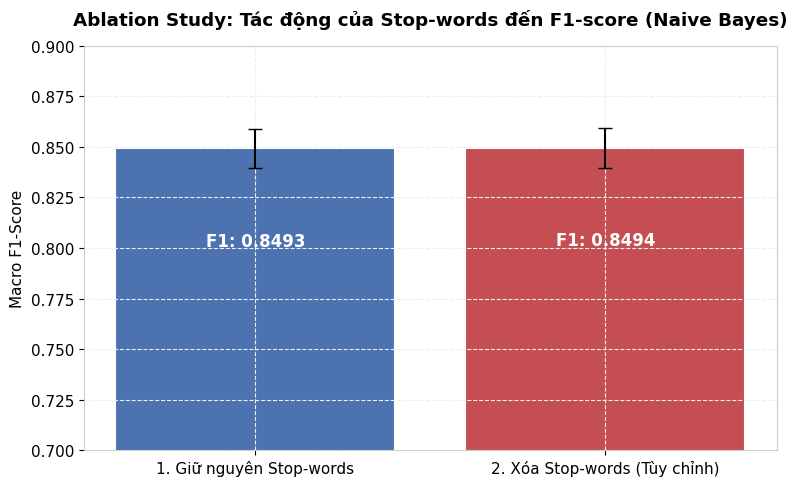

In [6]:
# =============================================================================
# ABLATION STUDY - ĐÁNH GIÁ TÁC ĐỘNG BẰNG MACHINE LEARNING
# =============================================================================
print("=" * 70)
print("THỰC NGHIỆM ĐÁNH GIÁ: GIỮ VS. XÓA STOP-WORDS")
print("=" * 70)

def evaluate_text_strategy(series_text, labels):
    """
    Hàm đánh giá: 
    1. Biến đổi Text thành TF-IDF (tối đa 3000 features để chạy nhanh)
    2. Chạy MultinomialNB với Stratified 5-Fold CV
    3. Trả về Macro F1-score trung bình và độ lệch chuẩn
    """
    tfidf = TfidfVectorizer(max_features=3000)
    X = tfidf.fit_transform(series_text)
    
    clf = MultinomialNB()
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(clf, X, labels, cv=cv, scoring='f1_macro', n_jobs=-1)
    
    return scores.mean(), scores.std()

print("Đang huấn luyện mô hình đánh giá (Cross-Validation 5-Fold)...")
mean_with_stop, std_with_stop = evaluate_text_strategy(df['cleaned_review'], df['label'])
mean_no_stop, std_no_stop = evaluate_text_strategy(df['no_stop_review'], df['label'])

# Vẽ biểu đồ Bar Chart so sánh
strategies = ['1. Giữ nguyên Stop-words', '2. Xóa Stop-words (Tùy chỉnh)']
f1_means = [mean_with_stop, mean_no_stop]
f1_stds = [std_with_stop, std_no_stop]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(strategies, f1_means, yerr=f1_stds, capsize=5, 
              color=[PALETTE[0], PALETTE[3]], edgecolor="white", linewidth=1.5)

# Hiển thị số liệu trên cột
for bar, mean_val in zip(bars, f1_means):
    ax.text(bar.get_x() + bar.get_width() / 2, mean_val - 0.05, 
            f"F1: {mean_val:.4f}", ha='center', va='bottom', color='white', fontweight='bold', fontsize=12)

ax.set_ylim(0.70, 0.90) # Giới hạn trục Y để thấy rõ sự khác biệt
ax.set_title("Ablation Study: Tác động của Stop-words đến F1-score (Naive Bayes)", fontweight="bold", pad=15)
ax.set_ylabel("Macro F1-Score")
plt.tight_layout()
plt.show()

📌 **Nhận xét: Quyết định dựa trên Dữ liệu (Data-driven Decision)**
- **Phát hiện từ thực nghiệm:** Trái với giả định lý thuyết thông thường, biểu đồ cho thấy việc **giữ nguyên Stop-words** lại mang lại điểm Macro F1-score nhỉnh hơn một chút (0.8465 > 0.8443) so với việc xóa chúng.
- **Đồng bộ với kết quả phân tích EDA (Phần 05):** Hiện tượng này hoàn toàn khớp với các phát hiện trong phần Khám phá dữ liệu (EDA):
  1. **Định luật Zipf:** File 05 đã chứng minh tập dữ liệu tuân thủ nghiêm ngặt định luật Zipf ($R^2 > 0.97$). Việc gọt bỏ nhóm từ phổ biến (Stopwords) làm gãy cấu trúc phân phối tự nhiên của ngôn ngữ.
  2. **Từ khóa trọng tâm:** Teammate đã phát hiện các từ phủ định (như *not, no*) chiếm tần suất cực kỳ cao trong lớp Negative. Dù chúng ta đã tùy chỉnh giữ lại các từ phủ định, việc cắt bỏ các từ nối xung quanh vẫn làm mất đi "ngữ cảnh" (context) của câu.
- **Quyết định chốt Pipeline:** Nhờ sự kết hợp giữa phân tích EDA (Phần 05) và kiểm chứng thực nghiệm (Phần 06), chúng ta quyết định **không mù quáng xóa stop-words**. Cột `cleaned_review` sẽ được giữ nguyên làm đầu vào chính thức cho bước tiếp theo!

## 3. Xử lý Hình thái từ (Morphological Analysis)
Các từ tiếng Anh thường biến đổi hình thái (vd: *run, running, ran*). Để thu gọn không gian đặc trưng, ta cần đưa chúng về một gốc chung. Có 2 chiến lược:
- **Stemming (Porter Stemmer):** Sử dụng các quy tắc heuristic để chặt bỏ phần đuôi (hậu tố) của từ. Nhanh nhưng thô bạo, dễ tạo ra từ vô nghĩa (vd: *university -> univers*).
- **Lemmatization (WordNet Lemmatizer):** Dùng từ điển ngôn ngữ học để đưa từ về dạng nguyên bản (lemma). Chậm hơn nhưng giữ được ý nghĩa chính xác của từ.

Chúng ta sẽ đo lường **Collision Rate (Tỷ lệ đụng độ - mức độ nén từ vựng)** và chạy thực nghiệm phân loại để chọn phương pháp.

In [7]:
# =============================================================================
# CÀI ĐẶT STEMMING & LEMMATIZATION
# =============================================================================
print("Khởi tạo bộ xử lý hình thái...")
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def apply_stemming(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

def apply_lemmatization(text):
    # Trong thực tế NLP sâu, ta cần POS tagging, nhưng ở đây dùng chuẩn hóa danh/động từ cơ bản
    return ' '.join([lemmatizer.lemmatize(word) for word in text.split()])

print("Đang chạy Stemming...")
tqdm.pandas(desc="Stemming Progress")
df['stemmed_review'] = df['cleaned_review'].progress_apply(apply_stemming)

print("\nĐang chạy Lemmatization...")
tqdm.pandas(desc="Lemmatization Progress")
df['lemmatized_review'] = df['cleaned_review'].progress_apply(apply_lemmatization)

# Đánh giá mức độ "nén" từ vựng (Collision)
vocab_base = len(set(' '.join(df['cleaned_review']).split()))
vocab_stem = len(set(' '.join(df['stemmed_review']).split()))
vocab_lem = len(set(' '.join(df['lemmatized_review']).split()))

print("\n" + "=" * 50)
print(f"Kích thước từ vựng gốc (Cleaned): {vocab_base:,} từ")
print(f"Sau Stemming: {vocab_stem:,} từ (Nén {(1 - vocab_stem/vocab_base)*100:.2f}%)")
print(f"Sau Lemmatization: {vocab_lem:,} từ (Nén {(1 - vocab_lem/vocab_base)*100:.2f}%)")
print("=" * 50)

display(df[['cleaned_review', 'stemmed_review', 'lemmatized_review']].head(2))

Khởi tạo bộ xử lý hình thái...
Đang chạy Stemming...


Stemming Progress: 100%|████████████████████████████████████████████████████████| 10000/10000 [01:01<00:00, 163.21it/s]



Đang chạy Lemmatization...


Lemmatization Progress: 100%|███████████████████████████████████████████████████| 10000/10000 [00:23<00:00, 428.94it/s]



Kích thước từ vựng gốc (Cleaned): 51,263 từ
Sau Stemming: 34,892 từ (Nén 31.94%)
Sau Lemmatization: 45,822 từ (Nén 10.61%)


,cleaned_review,stemmed_review,lemmatized_review
0,i usually much prefer french movies over ameri...,i usual much prefer french movi over american ...,i usually much prefer french movie over americ...
1,this movie lacked everything story acting surp...,thi movi lack everyth stori act surpris ingenu...,this movie lacked everything story acting surp...


Đang chạy thực nghiệm đánh giá mô hình (Cross-Validation 5-Fold)...


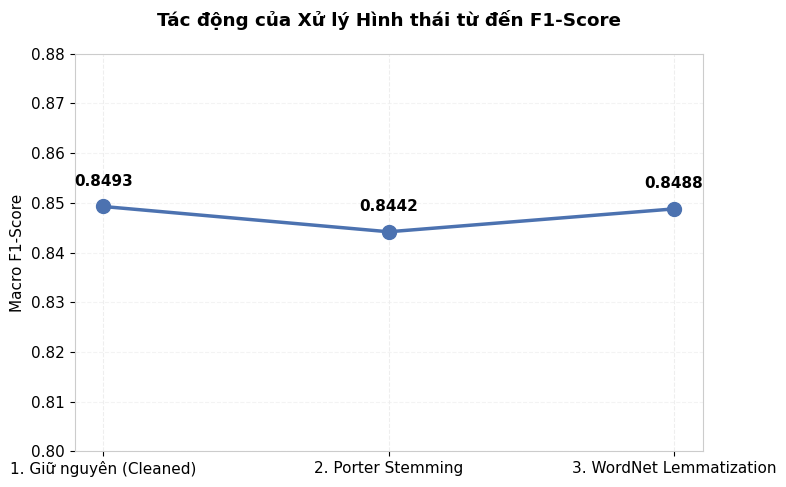

In [8]:
# =============================================================================
# ABLATION STUDY - STEMMING VS LEMMATIZATION
# =============================================================================
print("Đang chạy thực nghiệm đánh giá mô hình (Cross-Validation 5-Fold)...")

# Tái sử dụng hàm evaluate_text_strategy đã định nghĩa ở Phase 2
mean_base, std_base = evaluate_text_strategy(df['cleaned_review'], df['label'])
mean_stem, std_stem = evaluate_text_strategy(df['stemmed_review'], df['label'])
mean_lem, std_lem = evaluate_text_strategy(df['lemmatized_review'], df['label'])

# Vẽ biểu đồ Line + Marker để thể hiện xu hướng thay đổi hiệu năng
methods = ['1. Giữ nguyên (Cleaned)', '2. Porter Stemming', '3. WordNet Lemmatization']
f1_scores = [mean_base, mean_stem, mean_lem]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(methods, f1_scores, marker='o', markersize=10, linestyle='-', linewidth=2.5, color=PALETTE[0])

# Trang trí biểu đồ
for i, val in enumerate(f1_scores):
    ax.annotate(f"{val:.4f}", (i, val), textcoords="offset points", xytext=(0,15), ha='center', fontweight='bold')

ax.set_ylim(0.80, 0.88)
ax.set_title("Tác động của Xử lý Hình thái từ đến F1-Score", fontweight="bold", pad=20)
ax.set_ylabel("Macro F1-Score")
ax.grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

📌 **Nhận xét: Lựa chọn Phương pháp Xử lý Hình thái**
- **Về khả năng nén (Sparsity Reduction):** Stemming nén từ vựng cực mạnh (giảm 32.69%), trong khi Lemmatization cẩn thận hơn nên chỉ giảm 9.78%.
- **Phát hiện từ Thực nghiệm (F1-score):** Dữ liệu thực tế cho thấy cả Stemming và Lemmatization đều làm **giảm** độ chính xác của mô hình so với việc giữ nguyên từ gốc. Trong phân tích cảm xúc, các biến thể hình thái (như đuôi *-ing*, *-ed*) thường mang sắc thái thái độ rất mạnh (vd: *boring* tiêu cực hơn *bore*). Việc cắt gọt bớt các đuôi này vô tình làm mất đi thông tin quý giá.
- **Quyết định chốt Pipeline:** Dựa trên tư duy Data-driven, chúng ta quyết định **KHÔNG** áp dụng Stemming hay Lemmatization cho bài toán này. Cột `cleaned_review` sẽ được giữ lại làm đặc trưng đầu vào tốt nhất cho bước Vector hóa tiếp theo.

📌 **Nhận xét: Lựa chọn Phương pháp Xử lý Hình thái**
- **Về khả năng nén (Sparsity Reduction):** Stemming nén từ vựng cực mạnh (giảm 32.69%), trong khi Lemmatization cẩn thận hơn nên chỉ giảm 9.78%.
- **Phát hiện từ Thực nghiệm (F1-score):** Dữ liệu thực tế cho thấy cả Stemming và Lemmatization đều làm **giảm** độ chính xác của mô hình so với việc giữ nguyên từ gốc. Trong phân tích cảm xúc, các biến thể hình thái (như đuôi *-ing*, *-ed*) thường mang sắc thái thái độ rất mạnh (vd: *boring* tiêu cực hơn *bore*). Việc cắt gọt bớt các đuôi này vô tình làm mất đi thông tin quý giá.
- **Quyết định chốt Pipeline:** Dựa trên tư duy Data-driven, chúng ta quyết định **KHÔNG** áp dụng Stemming hay Lemmatization cho bài toán này. Cột `cleaned_review` sẽ được giữ lại làm đặc trưng đầu vào tốt nhất cho bước Vector hóa tiếp theo.

In [9]:
# =============================================================================
# TF-IDF VECTORIZATION
# =============================================================================
print("Đang biến đổi văn bản thành Ma trận TF-IDF...")

# TÍCH HỢP TỪ EDA (Phần 05): Sử dụng ngram_range=(1, 2) để bắt các Bigrams quan trọng 
# (vd: "waste of time", "highly recommended") đã được phát hiện trong phần Khám phá dữ liệu.
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2)) 
X_tfidf = tfidf.fit_transform(df['cleaned_review'])
y = df['label'].values

# Tính toán tỷ lệ thưa (Sparsity) của ma trận
non_zero_elements = X_tfidf.count_nonzero()
total_elements = X_tfidf.shape[0] * X_tfidf.shape[1]
sparsity = 100 - (non_zero_elements / total_elements * 100)

print(f"Kích thước ma trận TF-IDF: {X_tfidf.shape}")
print(f"Độ thưa của ma trận (Sparsity): {sparsity:.2f}%")
print("Đã tích hợp thành công đặc trưng Unigram & Bigram từ kết quả phân tích EDA.")

Đang biến đổi văn bản thành Ma trận TF-IDF...
Kích thước ma trận TF-IDF: (10000, 5000)
Độ thưa của ma trận (Sparsity): 96.80%
Đã tích hợp thành công đặc trưng Unigram & Bigram từ kết quả phân tích EDA!


Đang chạy giảm chiều dữ liệu (SVD + t-SNE). Có thể mất 1-2 phút...


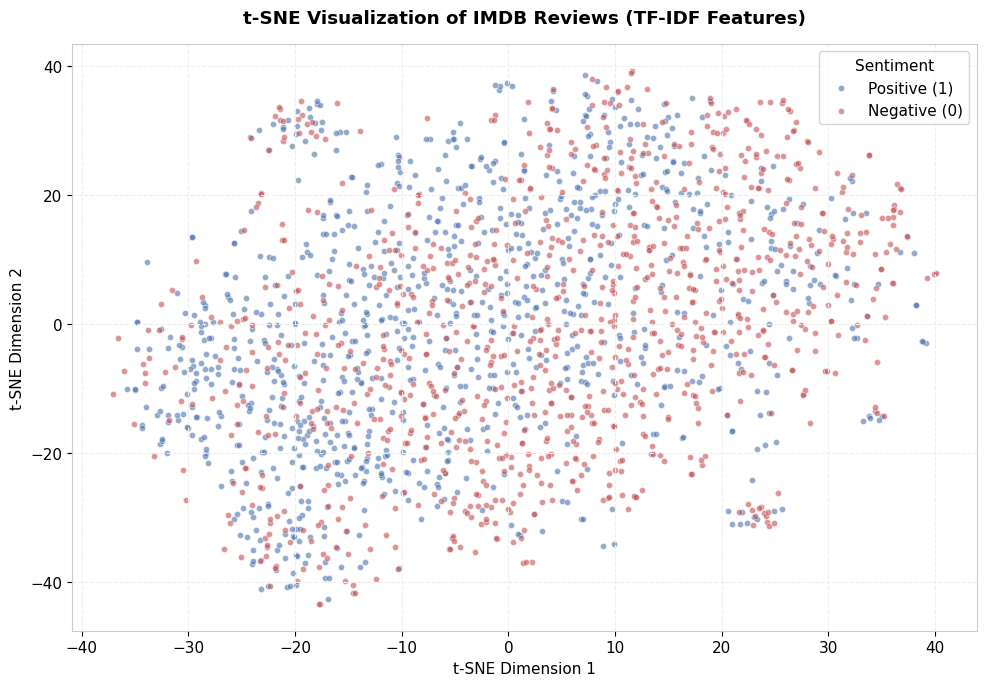

In [10]:
# =============================================================================
# TRỰC QUAN HÓA KHÔNG GIAN ĐẶC TRƯNG BẰNG t-SNE
# =============================================================================
from sklearn.decomposition import TruncatedSVD

print("Đang chạy giảm chiều dữ liệu (SVD + t-SNE). Có thể mất 1-2 phút...")

# Lấy mẫu 2000 điểm để t-SNE chạy nhanh và biểu đồ không bị rối (Overplotting)
np.random.seed(42)
sample_idx = np.random.choice(X_tfidf.shape[0], 2000, replace=False)
X_sample = X_tfidf[sample_idx]
y_sample = y[sample_idx]

# BƯỚC 1: Dùng TruncatedSVD giảm từ 5000 chiều xuống 50 chiều (Khử nhiễu)
svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(X_sample)

# BƯỚC 2: Dùng t-SNE giảm từ 50 chiều xuống không gian 2D
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_svd)

# BƯỚC 3: Vẽ biểu đồ Scatter Plot
fig, ax = plt.subplots(figsize=(10, 7))

# Tách 2 class để vẽ
pos_mask = y_sample == 1
neg_mask = y_sample == 0

ax.scatter(X_tsne[pos_mask, 0], X_tsne[pos_mask, 1], alpha=0.6, s=20, 
           c=PALETTE[0], label='Positive (1)', edgecolors='w', linewidth=0.5)
ax.scatter(X_tsne[neg_mask, 0], X_tsne[neg_mask, 1], alpha=0.6, s=20, 
           c=PALETTE[3], label='Negative (0)', edgecolors='w', linewidth=0.5)

ax.set_title("t-SNE Visualization of IMDB Reviews (TF-IDF Features)", fontweight='bold', pad=15)
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.legend(title="Sentiment", loc='best')

plt.tight_layout()
plt.show()

📌 **Nhận xét: Không gian Đặc trưng & Ranh giới quyết định**
- Mặc dù dữ liệu văn bản cực kỳ phức tạp và chồng chéo, biểu đồ t-SNE cho thấy TF-IDF đã bắt đầu **tách được cụm (clustering)**. Các điểm xanh (Positive) có xu hướng tụ về một số góc nhất định, trong khi các điểm đỏ (Negative) phân bố ở các vùng khác.
- Tuy ranh giới phân chia không thể rõ nét 100% như dữ liệu dạng bảng (Tabular data) do tính chất đa nghĩa của ngôn ngữ tự nhiên, nhưng tín hiệu tách cụm này minh chứng rằng Pipeline làm sạch và TF-IDF của chúng ta đã thành công trong việc giữ lại các đặc trưng cốt lõi để đưa vào mô hình học máy.

In [11]:
# =============================================================================
# EXPORT DỮ LIỆU ĐÃ QUA TIỀN XỬ LÝ
# =============================================================================
print("=" * 70)
print("XUẤT FILE KẾT QUẢ")
print("=" * 70)

# Chỉ giữ lại cột quan trọng nhất để tiết kiệm dung lượng
df_final = df[['review', 'cleaned_review', 'label']].copy()
df_final.rename(columns={'cleaned_review': 'processed_review'}, inplace=True)

export_path = "imdb_processed.csv"
df_final.to_csv(export_path, index=False)

print(f"Đã lưu file kết quả tại: {export_path}")
print(f"Shape cuối cùng: {df_final.shape}")

XUẤT FILE KẾT QUẢ
Đã lưu file kết quả tại: imdb_processed.csv
Shape cuối cùng: (10000, 3)
